Modelo Juan Felipe Echeverry

# Modelo de Regresión — Predicción de Puntaje Global Saber 11

**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Juan Felipe Echeverry  
**Rol:** Ciencia de Datos  

## Contexto

Este notebook desarrolla un modelo predictivo de regresión basado en redes neuronales para estimar el **puntaje global** que un estudiante obtendría en la prueba Saber 11, a partir de sus características socioeconómicas, demográficas y del colegio en el que estudia.

**Usuario final:** Secretaría de Educación de Bolívar.

**Pregunta de negocio:** ¿Qué factores socioeconómicos, demográficos y del entorno escolar permiten predecir el puntaje global Saber 11 de los estudiantes de Bolívar, y cómo puede la Secretaría de Educación estimar el puntaje esperado de distintos perfiles de estudiante para focalizar programas de refuerzo académico en las poblaciones con mayor riesgo de bajo desempeño?

## 1. Carga de datos limpios

Cargamos el dataframe ya procesado por el script de limpieza `Proyecto2.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('DatosSaber11_Bolivar_limpio_todas_columnas.csv')
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()
df.dtypes

Filas: 122,866
Columnas: 52


estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object
cole_cod_dane_es

## 2. Exploración del target: `punt_global`

El `punt_global` es nuestra variable objetivo. Está en escala 0–500 (suma ponderada de las áreas evaluadas). Revisamos su distribución antes de modelar.

In [3]:
df['punt_global'].describe()

count    122866.000000
mean        236.134561
std          48.642475
min           0.000000
25%         200.000000
50%         229.000000
75%         266.000000
max         475.000000
Name: punt_global, dtype: float64

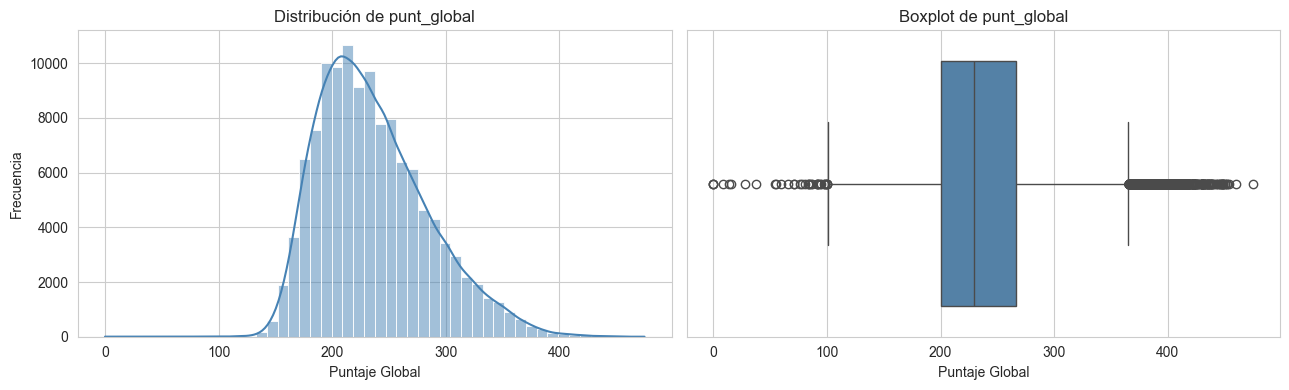

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma
sns.histplot(df['punt_global'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de punt_global')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df['punt_global'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de punt_global')
axes[1].set_xlabel('Puntaje Global')

plt.tight_layout()
plt.show()

In [5]:
# Verificación de valores nulos en el dataframe
nulos = df.isna().sum()
print("Columnas con nulos:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Ninguna columna tiene nulos.")

Columnas con nulos:
Ninguna columna tiene nulos.


## 3. Categorías de las variables ordinales

Antes de pasar al modelado, revisamos los valores únicos de las variables categóricas que vamos a tratar como ordinales (estrato, educación de padres, número de personas y cuartos en el hogar). Esto nos permite definir el mapeo correcto a valores numéricos.

In [6]:
variables_a_revisar = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
    'cole_jornada',
    'cole_caracter',
    'cole_calendario',
    'cole_naturaleza',
    'cole_genero',
    'estu_genero',
    'cole_bilingue',
    'cole_area_ubicacion',
]

for col in variables_a_revisar:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))


--- fami_estratovivienda ---
fami_estratovivienda
ESTRATO 1      69347
ESTRATO 2      28357
ESTRATO 3      13142
ESTRATO 4       4294
SIN ESTRATO     4136
ESTRATO 5       2101
ESTRATO 6       1489
Name: count, dtype: int64

--- fami_educacionmadre ---
fami_educacionmadre
SECUNDARIA (BACHILLERATO) COMPLETA      33159
SECUNDARIA (BACHILLERATO) INCOMPLETA    21277
PRIMARIA INCOMPLETA                     16979
PRIMARIA COMPLETA                       13821
TECNICA O TECNOLOGICA COMPLETA          11981
EDUCACION PROFESIONAL COMPLETA          11905
TECNICA O TECNOLOGICA INCOMPLETA         3873
NINGUNO                                  3184
NO SABE                                  2538
POSTGRADO                                2070
EDUCACION PROFESIONAL INCOMPLETA         1966
NO APLICA                                 113
Name: count, dtype: int64

--- fami_educacionpadre ---
fami_educacionpadre
SECUNDARIA (BACHILLERATO) COMPLETA      30321
SECUNDARIA (BACHILLERATO) INCOMPLETA    20307
PRIMARIA

## 4. Selección de features y exclusiones

Antes de modelar definimos qué variables usamos como predictoras (`features`) y cuáles descartamos.

### Variables excluidas

- **Por fuga de información (data leakage)**: las cinco pruebas individuales (`punt_ingles`, `punt_matematicas`, `punt_lectura_critica`, `punt_c_naturales`, `punt_sociales_ciudadanas`) y `desemp_ingles`. El puntaje global es función directa de esas pruebas, así que incluirlas convertiría la predicción en una operación aritmética sin valor.
- **Identificadores y códigos administrativos**: `estu_consecutivo`, `cole_cod_dane_establecimiento`, `cole_cod_dane_sede`, `cole_codigo_icfes`, `cole_cod_depto_ubicacion`, `cole_cod_mcpio_ubicacion`, `estu_cod_*`, `estu_tipodocumento`, `estu_estadoinvestigacion`, `estu_estudiante`.
- **Nombres propios (no generalizan)**: `cole_nombre_establecimiento`, `cole_nombre_sede`.
- **Variables casi constantes en Bolívar**: `estu_nacionalidad`, `estu_pais_reside`, `estu_privado_libertad`, `cole_sede_principal`, `cole_depto_ubicacion`, `estu_depto_presentacion`, `estu_depto_reside`.
- **Redundantes con `edad`**: `estu_fechanacimiento`.
- **Geográficas finas (decisión consciente, ver más adelante)**: `cole_mcpio_ubicacion`, `estu_mcpio_presentacion`, `estu_mcpio_reside`. Se excluyen en esta primera versión para evitar la explosión de columnas (46 municipios). Si el modelo lo justifica, se pueden incorporar en una iteración posterior.
- **Periodo**: `periodo`. No es predictor del puntaje individual, sino marcador temporal.

In [8]:
# Definimos las variables a usar como features
target = 'punt_global'

features_binarias = [
    'cole_bilingue',
    'cole_area_ubicacion',
    'cole_naturaleza',
    'fami_tieneautomovil',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tienelavadora',
    'estu_genero',
]

features_ordinales = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
]

features_nominales = [
    'cole_calendario',
    'cole_caracter',
    'cole_jornada',
    'cole_genero',
]

features_numericas = ['edad']

todas_las_features = (features_binarias + features_ordinales + 
                     features_nominales + features_numericas)

print(f"Total de features seleccionadas: {len(todas_las_features)}")
print(f"  - Binarias: {len(features_binarias)}")
print(f"  - Ordinales: {len(features_ordinales)}")
print(f"  - Nominales: {len(features_nominales)}")
print(f"  - Numéricas: {len(features_numericas)}")

Total de features seleccionadas: 18
  - Binarias: 8
  - Ordinales: 5
  - Nominales: 4
  - Numéricas: 1


In [9]:
# Construimos el dataframe de trabajo solo con features + target
df_modelo = df[todas_las_features + [target]].copy()
print(f"Shape df_modelo: {df_modelo.shape}")
df_modelo.head()

Shape df_modelo: (122866, 19)


,cole_bilingue,cole_area_ubicacion,cole_naturaleza,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,estu_genero,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_cuartoshogar,fami_personashogar,cole_calendario,cole_caracter,cole_jornada,cole_genero,edad,punt_global
0,N,URBANO,OFICIAL,No,NO,NO,Si,M,ESTRATO 1,SECUNDARIA (BACHILLERATO) COMPLETA,PRIMARIA COMPLETA,Uno,3 a 4,A,ACADEMICO,MAÑANA,MIXTO,17,226.0
1,N,URBANO,OFICIAL,No,SI,SI,Si,M,ESTRATO 3,EDUCACION PROFESIONAL COMPLETA,EDUCACION PROFESIONAL COMPLETA,Tres,5 a 6,A,TECNICO/ACADEMICO,TARDE,MIXTO,17,348.0
2,N,URBANO,OFICIAL,No,NO,NO,Si,F,ESTRATO 3,SECUNDARIA (BACHILLERATO) COMPLETA,NINGUNO,Tres,3 a 4,A,ACADEMICO,MAÑANA,MIXTO,16,160.0
3,N,RURAL,OFICIAL,No,NO,SI,Si,M,SIN ESTRATO,SECUNDARIA (BACHILLERATO) COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,Dos,3 a 4,A,ACADEMICO,MAÑANA,MIXTO,17,164.0
4,N,URBANO,OFICIAL,No,SI,SI,Si,F,ESTRATO 1,TECNICA O TECNOLOGICA INCOMPLETA,TECNICA O TECNOLOGICA INCOMPLETA,Tres,3 a 4,A,ACADEMICO,NOCHE,MIXTO,18,252.0


## 5. Codificación de variables

### 5.1 Variables binarias

Las variables binarias se convierten a 0/1. Mapeo:
- `cole_bilingue`: S → 1, N → 0
- `cole_area_ubicacion`: URBANO → 1, RURAL → 0
- `cole_naturaleza`: NO OFICIAL → 1, OFICIAL → 0
- `fami_tiene*`: Si → 1, No → 0
- `estu_genero`: M → 1, F → 0

In [10]:
# Primero exploramos los valores únicos de las binarias "fami_tiene*"
# (no las hemos revisado todavía)
for col in ['fami_tieneautomovil', 'fami_tienecomputador', 
            'fami_tieneinternet', 'fami_tienelavadora']:
    print(f"{col}: {df_modelo[col].unique()}")

fami_tieneautomovil: ['No' 'Si']
fami_tienecomputador: ['NO' 'SI']
fami_tieneinternet: ['NO' 'SI']
fami_tienelavadora: ['Si' 'No']


Las binarias vienen con formatos mezclados ("Si"/"No" en algunas columnas, "SI"/"NO" en otras). Lo normalizamos a un solo mapeo aceptando ambos.

In [11]:
mapeo_si_no = {'SI': 1, 'Si': 1, 'NO': 0, 'No': 0}

df_modelo['cole_bilingue'] = df_modelo['cole_bilingue'].map({'S': 1, 'N': 0})
df_modelo['cole_area_ubicacion'] = df_modelo['cole_area_ubicacion'].map({'URBANO': 1, 'RURAL': 0})
df_modelo['cole_naturaleza'] = df_modelo['cole_naturaleza'].map({'NO OFICIAL': 1, 'OFICIAL': 0})
df_modelo['fami_tieneautomovil'] = df_modelo['fami_tieneautomovil'].map(mapeo_si_no)
df_modelo['fami_tienecomputador'] = df_modelo['fami_tienecomputador'].map(mapeo_si_no)
df_modelo['fami_tieneinternet'] = df_modelo['fami_tieneinternet'].map(mapeo_si_no)
df_modelo['fami_tienelavadora'] = df_modelo['fami_tienelavadora'].map(mapeo_si_no)
df_modelo['estu_genero'] = df_modelo['estu_genero'].map({'M': 1, 'F': 0})

print("Nulos después del mapeo binario:")
print(df_modelo[features_binarias].isna().sum())

Nulos después del mapeo binario:
cole_bilingue           0
cole_area_ubicacion     0
cole_naturaleza         0
fami_tieneautomovil     0
fami_tienecomputador    0
fami_tieneinternet      0
fami_tienelavadora      0
estu_genero             0
dtype: int64


### 5.2 Variables ordinales

Convertimos a un número entero respetando el orden natural de cada variable.

- **Estrato vivienda**: "SIN ESTRATO" se mapea a 0, Estratos 1–6 a 1–6.
- **Educación de padres**: 0 (ninguno / no sabe / no aplica) hasta 9 (postgrado). Las categorías "NO SABE" y "NO APLICA" se asignan a 0 por baja representatividad (<3%) y porque tienden a coincidir con perfiles de baja escolaridad.
- **Cuartos y personas del hogar**: se unifican los formatos mezclados (palabras como "Dos", rangos como "3 a 4", etc.) a un único entero.

In [12]:
# Estrato
mapa_estrato = {
    'SIN ESTRATO': 0,
    'ESTRATO 1': 1, 'ESTRATO 2': 2, 'ESTRATO 3': 3,
    'ESTRATO 4': 4, 'ESTRATO 5': 5, 'ESTRATO 6': 6,
}
df_modelo['fami_estratovivienda'] = df_modelo['fami_estratovivienda'].map(mapa_estrato)

# Educación padre y madre
mapa_educacion = {
    'NINGUNO': 0, 'NO SABE': 0, 'NO APLICA': 0,
    'PRIMARIA INCOMPLETA': 1,
    'PRIMARIA COMPLETA': 2,
    'SECUNDARIA (BACHILLERATO) INCOMPLETA': 3,
    'SECUNDARIA (BACHILLERATO) COMPLETA': 4,
    'TECNICA O TECNOLOGICA INCOMPLETA': 5,
    'TECNICA O TECNOLOGICA COMPLETA': 6,
    'EDUCACION PROFESIONAL INCOMPLETA': 7,
    'EDUCACION PROFESIONAL COMPLETA': 8,
    'POSTGRADO': 9,
}
df_modelo['fami_educacionmadre'] = df_modelo['fami_educacionmadre'].map(mapa_educacion)
df_modelo['fami_educacionpadre'] = df_modelo['fami_educacionpadre'].map(mapa_educacion)

# Cuartos del hogar
mapa_cuartos = {
    'Uno': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4, 'Cinco': 5,
    'Seis': 6, 'Seis o mas': 6, 'Siete': 7, 'Ocho': 8, 
    'Nueve': 9, 'Diez o más': 10,
}
df_modelo['fami_cuartoshogar'] = df_modelo['fami_cuartoshogar'].map(mapa_cuartos)

# Personas del hogar (formatos mezclados)
mapa_personas = {
    'Una': 1, '1 a 2': 1,
    'Dos': 2,
    'Tres': 3, '3 a 4': 3,
    'Cuatro': 4,
    'Cinco': 5, '5 a 6': 5,
    'Seis': 6,
    'Siete': 7, '7 a 8': 7,
    'Ocho': 8,
    'Nueve': 9, '9 o más': 9,
    'Diez': 10,
    'Once': 11,
    'Doce o más': 12,
}
df_modelo['fami_personashogar'] = df_modelo['fami_personashogar'].map(mapa_personas)

print("Nulos después del mapeo ordinal:")
print(df_modelo[features_ordinales].isna().sum())

Nulos después del mapeo ordinal:
fami_estratovivienda    0
fami_educacionmadre     0
fami_educacionpadre     0
fami_cuartoshogar       0
fami_personashogar      0
dtype: int64


### 5.3 Variables nominales

Para las categóricas sin orden natural usamos **one-hot encoding** con `pd.get_dummies` (mismo enfoque del starter de clase con la variable `Origin`).

In [13]:
df_modelo = pd.get_dummies(
    df_modelo, 
    columns=features_nominales, 
    prefix=features_nominales,
    dtype=int
)

print(f"Shape después de one-hot: {df_modelo.shape}")
df_modelo.head()

Shape después de one-hot: (122866, 30)


,cole_bilingue,cole_area_ubicacion,cole_naturaleza,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,estu_genero,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_cuartoshogar,fami_personashogar,edad,punt_global,cole_calendario_A,cole_calendario_B,cole_caracter_ACADEMICO,cole_caracter_NO APLICA,cole_caracter_TECNICO,cole_caracter_TECNICO/ACADEMICO,cole_jornada_COMPLETA,cole_jornada_MAÑANA,cole_jornada_NOCHE,cole_jornada_SABATINA,cole_jornada_TARDE,cole_jornada_UNICA,cole_genero_FEMENINO,cole_genero_MASCULINO,cole_genero_MIXTO
0,0,1,0,0,0,0,1,1,1,4,2,1,3,17,226.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
1,0,1,0,0,1,1,1,1,3,8,8,3,5,17,348.0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1
2,0,1,0,0,0,0,1,0,3,4,0,3,3,16,160.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
3,0,0,0,0,0,1,1,1,0,4,4,2,3,17,164.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1
4,0,1,0,0,1,1,1,0,1,5,5,3,3,18,252.0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1


In [14]:
print("Tipos de datos del df_modelo:")
print(df_modelo.dtypes)
print("\nNulos totales en df_modelo:", df_modelo.isna().sum().sum())

Tipos de datos del df_modelo:
cole_bilingue                        int64
cole_area_ubicacion                  int64
cole_naturaleza                      int64
fami_tieneautomovil                  int64
fami_tienecomputador                 int64
fami_tieneinternet                   int64
fami_tienelavadora                   int64
estu_genero                          int64
fami_estratovivienda                 int64
fami_educacionmadre                  int64
fami_educacionpadre                  int64
fami_cuartoshogar                    int64
fami_personashogar                   int64
edad                                 int64
punt_global                        float64
cole_calendario_A                    int64
cole_calendario_B                    int64
cole_caracter_ACADEMICO              int64
cole_caracter_NO APLICA              int64
cole_caracter_TECNICO                int64
cole_caracter_TECNICO/ACADEMICO      int64
cole_jornada_COMPLETA                int64
cole_jornada_MAÑANA     

In [15]:
print(f"Shape final del df_modelo: {df_modelo.shape}")
print(f"\nLista completa de columnas:")
for col in df_modelo.columns:
    print(f"  - {col}")

Shape final del df_modelo: (122866, 30)

Lista completa de columnas:
  - cole_bilingue
  - cole_area_ubicacion
  - cole_naturaleza
  - fami_tieneautomovil
  - fami_tienecomputador
  - fami_tieneinternet
  - fami_tienelavadora
  - estu_genero
  - fami_estratovivienda
  - fami_educacionmadre
  - fami_educacionpadre
  - fami_cuartoshogar
  - fami_personashogar
  - edad
  - punt_global
  - cole_calendario_A
  - cole_calendario_B
  - cole_caracter_ACADEMICO
  - cole_caracter_NO APLICA
  - cole_caracter_TECNICO
  - cole_caracter_TECNICO/ACADEMICO
  - cole_jornada_COMPLETA
  - cole_jornada_MAÑANA
  - cole_jornada_NOCHE
  - cole_jornada_SABATINA
  - cole_jornada_TARDE
  - cole_jornada_UNICA
  - cole_genero_FEMENINO
  - cole_genero_MASCULINO
  - cole_genero_MIXTO


## 6. Análisis exploratorio post-encoding

Antes de modelar revisamos:
1. La **correlación de cada feature con el target** (`punt_global`) para identificar las variables con mayor poder predictivo lineal.
2. La **matriz de correlación entre features** para detectar multicolinealidad (variables que aportan información redundante).

Aunque las redes neuronales pueden capturar relaciones no lineales y no son tan sensibles a la multicolinealidad como la regresión lineal clásica, estos análisis son útiles para interpretar el problema y justificar decisiones de modelado.

In [16]:
# Correlación de cada feature con el target
corr_target = df_modelo.corr()['punt_global'].drop('punt_global').sort_values(key=abs, ascending=False)

print("Correlación de cada feature con punt_global (ordenada por magnitud):\n")
print(corr_target.to_string())

Correlación de cada feature con punt_global (ordenada por magnitud):

fami_educacionmadre                0.404239
cole_naturaleza                    0.391706
fami_educacionpadre                0.379307
fami_tieneinternet                 0.324898
fami_tienecomputador               0.324644
cole_jornada_COMPLETA              0.319473
fami_estratovivienda               0.281466
fami_tieneautomovil                0.242506
cole_calendario_B                  0.233642
cole_calendario_A                 -0.233642
edad                              -0.232240
cole_jornada_NOCHE                -0.212338
cole_caracter_ACADEMICO            0.185430
cole_genero_MIXTO                 -0.185097
cole_caracter_TECNICO             -0.181943
cole_area_ubicacion                0.179709
cole_genero_FEMENINO               0.176141
cole_bilingue                      0.159233
fami_tienelavadora                 0.140696
cole_jornada_SABATINA             -0.139489
fami_personashogar                -0.114026
cole_g

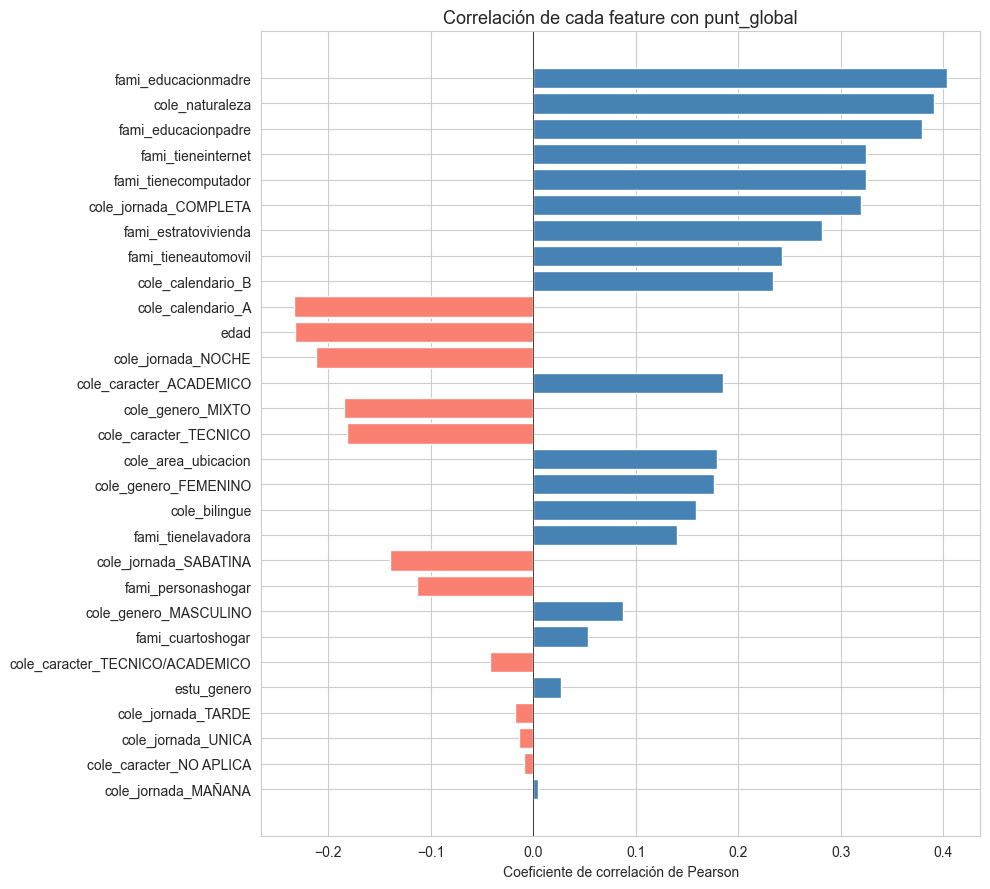

In [17]:
# Visualización: correlaciones con el target en barras horizontales
plt.figure(figsize=(10, 9))
colors = ['steelblue' if x > 0 else 'salmon' for x in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.title('Correlación de cada feature con punt_global', fontsize=13)
plt.xlabel('Coeficiente de correlación de Pearson')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()